In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense,Dropout,Conv2D, MaxPooling2D, Rescaling, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf


In [ ]:
# Download Data
path = kagglehub.dataset_download("shuvokumarbasak4004/chili-plant-disease-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chili-plant-disease-detection' dataset.
Path to dataset files: /kaggle/input/chili-plant-disease-detection


In [ ]:
sehat = len(os.listdir(os.path.join(path, "train", "healthy")))
sakit = len(os.listdir(os.path.join(path, "train", "unhealthy")))

print("Sehat:", sehat)
print("Tidak Sehat:", sakit)

Sehat: 100
Tidak Sehat: 100


In [ ]:
import tensorflow as tf
import os

train_dir = os.path.join(path, "train")

image_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.
['healthy', 'unhealthy']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224,224,3)),

    tf.keras.layers.Rescaling(1./255),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_7 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.5813 - loss: 2.3956 - val_accuracy: 0.5000 - val_loss: 0.7192
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.5375 - loss: 0.7363 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.5000 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5000 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.7009
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4875 - loss: 0.7030 - val_accuracy: 0.5000 - val_loss: 0.6745
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5000 - loss: 0.6762 - val_accuracy: 0.5500 - val_loss: 0.6573
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6000 - loss: 0.6611 - val_accuracy: 0.7250 - val_loss: 0.6310
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7000 - loss: 0.6177 - val_accuracy: 0.5250 - val_loss: 0.6023
Epoch 9/

In [ ]:
loss, acc = model.evaluate(val_ds)

print("Akurasi Validasi:", acc)
print("Loss Validasi:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.9250 - loss: 0.2381
Akurasi Validasi: 0.925000011920929
Loss Validasi: 0.23808999359607697


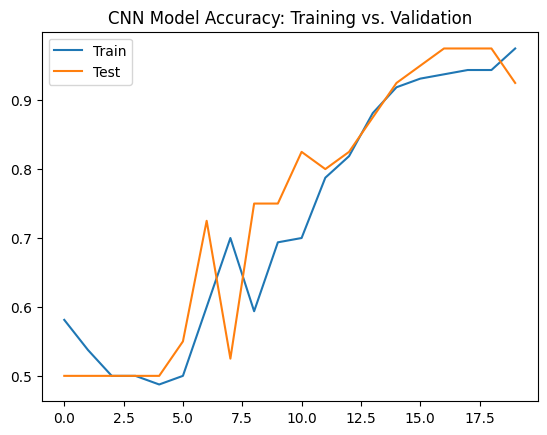

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Model Accuracy: Training vs. Validation')
plt.legend(['Train', 'Test'])
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

y_true = np.concatenate([y for x, y in val_ds], axis=0)


val_ds_for_prediction = val_ds.map(lambda x, y: tf.image.resize(x, (224, 224)))

# Prediksi model
y_pred = model.predict(val_ds_for_prediction)

y_pred = (y_pred > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step
Confusion Matrix:
 [[20  0]
 [ 3 17]]

Classification Report:

              precision    recall  f1-score   support

     healthy       0.87      1.00      0.93        20
   unhealthy       1.00      0.85      0.92        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



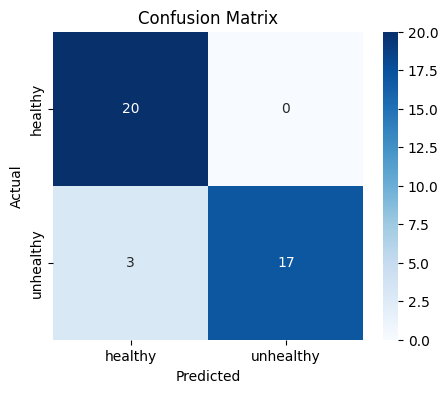

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


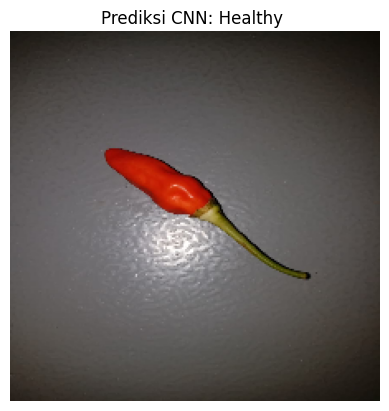

Nilai prediksi: 1.4637778e-13
Hasil klasifikasi: Healthy


In [ ]:
# Load gambar

img_path = '/content/cabai bagus.jpeg'
img = image.load_img(img_path, target_size=(224,224))

# Convert ke array
img_array = image.img_to_array(img)

# Normalisasi
img_array = img_array / 255.0

# Tambah batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediksi
prediction = model.predict(img_array)

# Tentukan label
label = "Healthy" if prediction[0][0] < 0.5 else "Unhealthy"

plt.imshow(img)
plt.title(f"Prediksi CNN: {label} ")
plt.axis('off')
plt.show()
print("Nilai prediksi:", prediction[0][0])
print("Hasil klasifikasi:", label)

# **KKN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import numpy as np

def extract_data(dataset):
    X = []
    y = []

    for images, labels in dataset:
        for img, label in zip(images, labels):
            X.append(img.numpy().flatten())  # flatten gambar
            y.append(label.numpy())

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = extract_data(train_ds)
X_val, y_val = extract_data(val_ds)

print(X_train.shape)

(160, 150528)


In [ ]:
X_train = X_train / 255.0
X_val = X_val / 255.0

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_val)

In [ ]:
print("Akurasi KNN:", accuracy_score(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=class_names))

Akurasi KNN: 0.85
Confusion Matrix:
 [[16  4]
 [ 2 18]]

Classification Report:

              precision    recall  f1-score   support

     healthy       0.89      0.80      0.84        20
   unhealthy       0.82      0.90      0.86        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



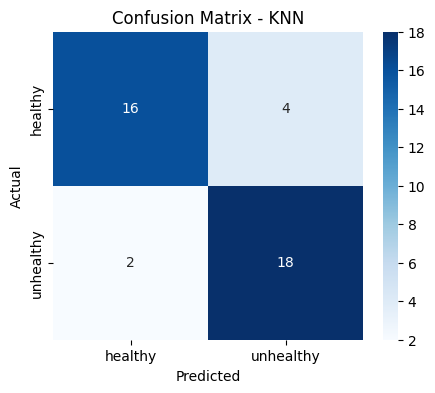

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

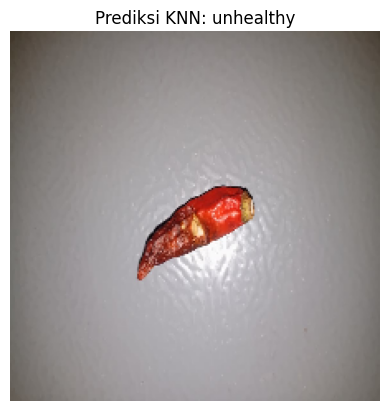

Hasil: unhealthy


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = '/content/cabai rawit busuk.jpeg'

# Load gambar
img = image.load_img(img_path, target_size=(224, 224))

# Convert ke array
img_array = image.img_to_array(img)

# Flatten
img_array = img_array.flatten()

# Normalisasi
img_array = img_array / 255.0

# Tambah batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediksi KNN
prediction = knn.predict(img_array)

# Label
label = class_names[prediction[0]]


plt.imshow(img)
plt.title(f"Prediksi KNN: {label}")
plt.axis('off')
plt.show()

print("Hasil:", label)

/tmp/ipykernel_4131/3280257717.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracy_values, palette='viridis')


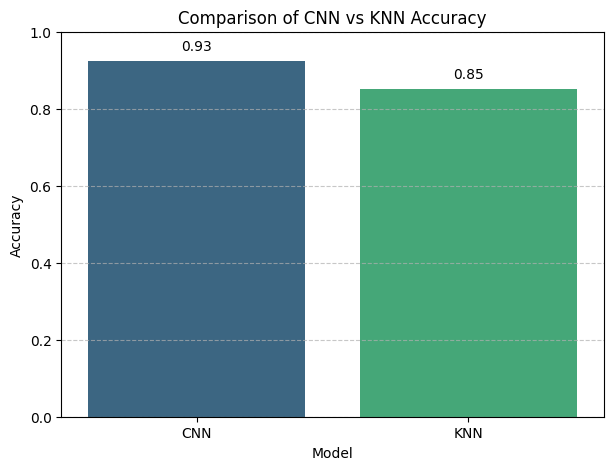

In [ ]:
cnn_acc = acc
knn_acc = accuracy_score(y_val, y_pred)

models = ['CNN', 'KNN']
accuracy_values = [cnn_acc, knn_acc]

plt.figure(figsize=(7, 5))
sns.barplot(x=models, y=accuracy_values, palette='viridis')
plt.title('Comparison of CNN vs KNN Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, value in enumerate(accuracy_values):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center', va='bottom')

plt.show()